# TP 3 — Sélection d'estimateurs : solution commentée

Solution complète du [TP 3](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

data = load_breast_cancer()
X, y = data.data, data.target

## Exercice 1 — Comparaison par CV répétée

logreg   F1 = 0.9805 ± 0.0126
svm      F1 = 0.9792 ± 0.0089
rf       F1 = 0.9721 ± 0.0099
gbm      F1 = 0.9683 ± 0.0107


/var/folders/8m/l_690lqs2v51h4cv_vz7lllr0000gn/T/ipykernel_73742/3440154167.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(results.values(), labels=results.keys(), showmeans=True)


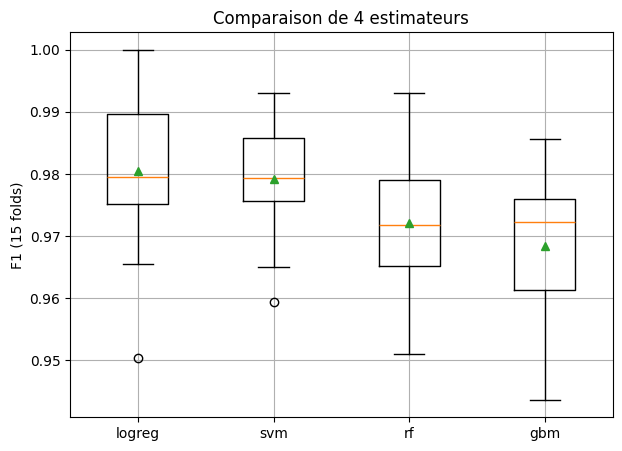

In [2]:
estimators = {
    "logreg": Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=2000))]),
    "svm": Pipeline([("sc", StandardScaler()), ("clf", SVC(kernel="rbf"))]),
    "rf": RandomForestClassifier(n_estimators=200, random_state=0),
    "gbm": GradientBoostingClassifier(random_state=0),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=0)
results = {name: cross_val_score(m, X, y, cv=cv, scoring="f1") for name, m in estimators.items()}

for name, s in results.items():
    print(f"{name:7s}  F1 = {s.mean():.4f} ± {s.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(results.values(), labels=results.keys(), showmeans=True)
ax.set_ylabel("F1 (15 folds)")
ax.set_title("Comparaison de 4 estimateurs")
ax.grid(True)

## Exercice 2 — Courbe d'apprentissage du meilleur

meilleur : logreg


Text(0.5, 1.0, "Courbe d'apprentissage — logreg")

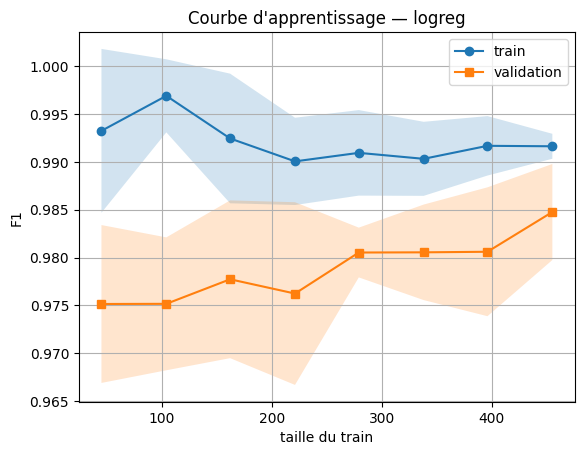

In [3]:
best_name = max(results, key=lambda n: np.median(results[n]))
best = estimators[best_name]
print("meilleur :", best_name)

sizes, tr, val = learning_curve(
    best,
    X,
    y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=0,
    shuffle=True,
)
tr_mean, tr_std = tr.mean(axis=1), tr.std(axis=1)
va_mean, va_std = val.mean(axis=1), val.std(axis=1)

plt.plot(sizes, tr_mean, "o-", label="train")
plt.fill_between(sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2)
plt.plot(sizes, va_mean, "s-", label="validation")
plt.fill_between(sizes, va_mean - va_std, va_mean + va_std, alpha=0.2)
plt.xlabel("taille du train")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.title(f"Courbe d'apprentissage — {best_name}")

## Exercice 3 — Arbre sans régularisation

Text(0.5, 1.0, 'Arbre sans limite de profondeur — sur-apprentissage caractéristique')

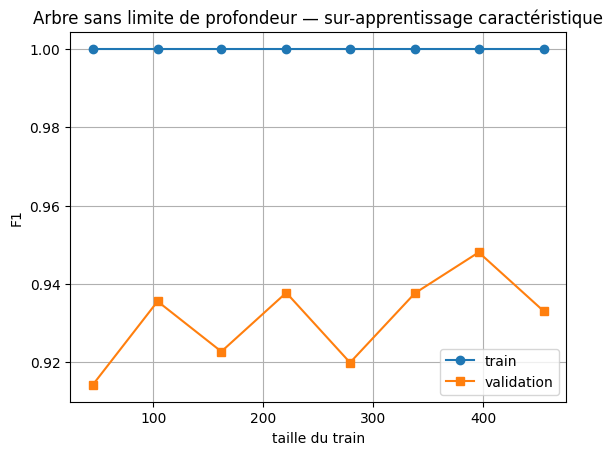

In [4]:
tree = DecisionTreeClassifier(max_depth=None, random_state=0)
sizes, tr, val = learning_curve(
    tree,
    X,
    y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=0,
    shuffle=True,
)
tr_mean, va_mean = tr.mean(axis=1), val.mean(axis=1)

plt.plot(sizes, tr_mean, "o-", label="train")
plt.plot(sizes, va_mean, "s-", label="validation")
plt.xlabel("taille du train")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.title("Arbre sans limite de profondeur — sur-apprentissage caractéristique")

**Diagnostic** : l'accuracy train est très proche de 1.0 sur toutes les tailles, alors que la validation plafonne plus bas. C'est le signe typique du **sur-apprentissage**. Remèdes :

1. **Régulariser** l'arbre via `max_depth`, `min_samples_leaf`, `min_samples_split`.
2. **Ensemblage** : remplacer l'arbre par une forêt aléatoire ou du gradient boosting.
3. **Plus de données** d'entraînement, si possible.